In [87]:
# Plota saidas do SWAN com arquivos .mat (e nc?)

In [88]:
import pandas as pd
import h5py
import xarray as xr
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipympl

In [89]:
pth = 'RJ/Outputs/'
fln = 'RJ_teste_01'

grid = scipy.io.loadmat(pth + f'{fln}_grid.mat')
param = scipy.io.loadmat(pth + f'{fln}_param.mat')
bot = scipy.io.loadmat(pth + f'{fln}_bot.mat')

In [90]:
bot = bot['Botlev']
swh = param['Hsig']
lons = grid['Xp']
lats = grid['Yp']
lat = lats[:, 0]
lon = lons[0, :]

/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


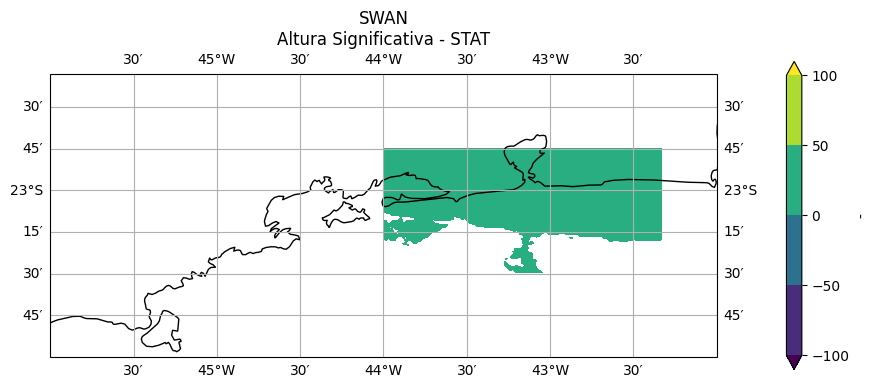

In [91]:
%matplotlib inline

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                    #    subplot_kw={'projection': ccrs.Mercator()}
                       )

ax.coastlines(resolution='10m')

c = ax.contourf(lon, lat, np.flipud(swh),
                levels=[-100, -50, 0, 50, 100],
                extend='both',
                cmap='viridis',
                transform=ccrs.PlateCarree(),
                # transform=ccrs.Mercator(),
                )

# Adicionar as linhas de grade com a resolução do modelo
# for lat in lat:
#     ax.plot(lon, np.full_like(lon, lat), color='black', linewidth=0.3)  # Linhas horizontais (latitude)

# for lon in lon:
#     ax.plot(np.full_like(lat, lon), lat, color='black', linewidth=0.3)  # Linhas verticais (longitude)

# ax.set_xticks(longitude)  # Configura as ticks de longitude
# ax.set_yticks(latitude)  # Configura as ticks de latitude

# Adicionar as linhas de grade (latitude e longitude)

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# ax.plot(-43.313725, -23.277778, 'o', color='red')

# Adicionar uma barra de cores
fig.colorbar(c, ax=ax, orientation='vertical',
                                        shrink=0.4,  # Reduz o tamanho da barra
                                        pad=0.09,  # Aproxima da figura
                                        aspect=20,  # Ajusta proporção altura/largura
                                        fraction=0.05,  # Reduz o espaço ocupado, 
                                        label='-')

# Título do gráfico
ax.set_title('SWAN\nAltura Significativa - STAT')

ax.set_extent([-46, -42, -24.0, -22.3], crs=ccrs.PlateCarree())

plt.show()
# fig.savefig('fig/RJ_1km_ERA5_050_20241101to20241130/mapa_Hs_{:%Y%m%d%H}.png'.format(datet), bbox_inches='tight')
# plt.close('all')

TypeError: Inputs x and y must be 1D or 2D, not 0D

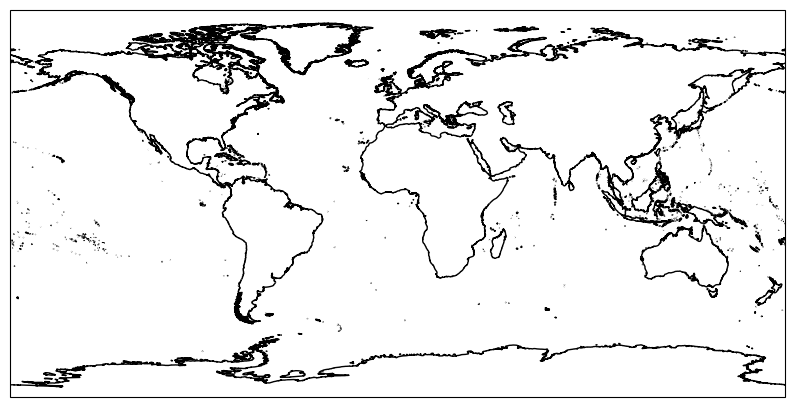

In [105]:
%matplotlib inline

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                    #    subplot_kw={'projection': ccrs.Mercator()}
                       )

ax.coastlines(resolution='10m')

c = ax.contourf(lon, lat, swh,
                # levels=[-100, -50, 0, 50, 100],
                extend='both',
                cmap='viridis',
                transform=ccrs.PlateCarree(),
                # transform=ccrs.Mercator(),
                )

# Adicionar as linhas de grade com a resolução do modelo
for lat in lat:
    ax.plot(lon, np.full_like(lon, lat), color='black', linewidth=0.3)  # Linhas horizontais (latitude)

for lon in lon:
    ax.plot(np.full_like(lat, lon), lat, color='black', linewidth=0.3)  # Linhas verticais (longitude)

# ax.set_xticks(longitude)  # Configura as ticks de longitude
# ax.set_yticks(latitude)  # Configura as ticks de latitude

# Adicionar as linhas de grade (latitude e longitude)

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# ax.plot(-43.313725, -23.277778, 'o', color='red')

# Adicionar uma barra de cores
fig.colorbar(c, ax=ax, orientation='vertical',
                                        shrink=0.4,  # Reduz o tamanho da barra
                                        pad=0.09,  # Aproxima da figura
                                        aspect=20,  # Ajusta proporção altura/largura
                                        fraction=0.05,  # Reduz o espaço ocupado, 
                                        label='-')

# Título do gráfico
ax.set_title('SWAN\nAltura Significativa - STAT')

ax.set_extent([-43.9, -42.5, -23.5, -22.3], crs=ccrs.PlateCarree())

plt.show()
# fig.savefig('fig/RJ_1km_ERA5_050_20241101to20241130/mapa_Hs_{:%Y%m%d%H}.png'.format(datet), bbox_inches='tight')
# plt.close('all')

In [93]:
# # Criar o DataArray usando xarray

# swh_data = xr.DataArray(Hss, 
#                         coords=[datas, latitude, longitude], 
#                         dims=["time", "latitude", "longitude"], 
#                         name="significant_wave_height")

# swh_data.attrs["units"] = "Meters"
# swh_data.attrs["long_name"] = "Significant Wave Height"

# ds_swh = xr.Dataset({"swh": swh_data})
# # ds_swh.to_netcdf('RJ/Outputs/RJ_5km/H-sig.nc')

In [94]:
# # carrega era5

# ds_era5 = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-wave_stepType-instant.nc')


In [95]:
# df_swh = ds_swh.sel(latitude=-23.30, longitude=-43.3, method='nearest').to_dataframe()
# df_era5 = ds_era5.sel(latitude=-23.2765071, longitude=-43.2760040, method='nearest').to_dataframe()
# df_swh

In [96]:
# df_swh.swh.plot(figsize=(8, 4), grid='on')
# df_era5.swh.plot(figsize=(8, 4), grid='on')
